In [1]:
# ============================================
# 04_model_training.ipynb
# Project: Customer Churn Analysis
# Purpose: Train and evaluate churn prediction models — logistic regression and random forest.
#          Compare performance and build churn risk scorecard.
# ============================================

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Visualisation style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# Load prepared datasets from notebook 03
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print("=== DATASETS LOADED ===")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")
print(f"\nReady to train models")

=== DATASETS LOADED ===
X_train: (5634, 28)
X_test:  (1409, 28)
y_train: (5634,)
y_test:  (1409,)

Ready to train models


In [2]:
# ============================================
# Cell 2: Logistic Regression Model
# Purpose: Train baseline churn prediction model
# Logistic regression is always the first model to try — fast, interpretable, good baseline
# ============================================

# Initialise model
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,        # max iterations to converge
    class_weight='balanced'  # handles class imbalance
)

# Train model
lr_model.fit(X_train, y_train)

# Make predictions
lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

print("=== LOGISTIC REGRESSION RESULTS ===")
print(f"\nModel trained on {X_train.shape[0]:,} customers")
print(f"Evaluated on    {X_test.shape[0]:,} customers")

print(f"\n=== CLASSIFICATION REPORT ===")
print(classification_report(
    y_test, lr_pred,
    target_names=['Retained', 'Churned']
))

print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_prob):.4f}")

=== LOGISTIC REGRESSION RESULTS ===

Model trained on 5,634 customers
Evaluated on    1,409 customers

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Retained       0.90      0.75      0.82      1035
     Churned       0.53      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409

ROC-AUC Score: 0.8425


In [3]:
# ============================================
# Cell 3: Random Forest Model
# Purpose: Train more powerful ensemble model and compare against logistic regression
# Random forest builds hundreds of decision trees and combines their predictions — reduces variance
# and handles non-linear patterns better than logistic regression
# ============================================

# Initialise model
rf_model = RandomForestClassifier(
    n_estimators=100,        # number of trees
    max_depth=10,            # max depth per tree
    min_samples_split=10,    # min samples to split node
    min_samples_leaf=4,      # min samples per leaf
    class_weight='balanced', # handles class imbalance
    random_state=42,         # reproducibility
    n_jobs=-1                # use all CPU cores
)

# Train model
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("=== RANDOM FOREST RESULTS ===")
print(f"\nModel trained on {X_train.shape[0]:,} customers")
print(f"Evaluated on    {X_test.shape[0]:,} customers")

print(f"\n=== CLASSIFICATION REPORT ===")
print(classification_report(
    y_test, rf_pred,
    target_names=['Retained', 'Churned']
))

print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_prob):.4f}")

=== RANDOM FOREST RESULTS ===

Model trained on 5,634 customers
Evaluated on    1,409 customers

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Retained       0.88      0.78      0.83      1035
     Churned       0.54      0.72      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409

ROC-AUC Score: 0.8377


In [4]:
# ============================================
# Cell 3b: XGBoost Model
# Purpose: Train industry standard gradient boosting model and compare against logistic regression and random forest
#
# How XGBoost differs from Random Forest:
# Random Forest — builds trees in PARALLEL each tree independent averages predictions
#
# XGBoost — builds trees SEQUENTIALLY each tree corrects errors of the previous tree
#           focuses progressively on harder to predict customers
# ============================================

from xgboost import XGBClassifier

# Calculate class weight ratio for imbalanced data
# XGBoost uses scale_pos_weight instead of class_weight
neg = (y_train == 0).sum()  # retained
pos = (y_train == 1).sum()  # churned
scale = neg / pos

print(f"Class balance ratio: {scale:.2f}")
print(f"Retained: {neg:,}, Churned: {pos:,}")

# Initialise model
xgb_model = XGBClassifier(
    n_estimators=100,          # number of trees
    max_depth=6,               # shallower than RF — XGBoost prefers this
    learning_rate=0.1,         # how much each tree contributes
    subsample=0.8,             # % of rows per tree
    colsample_bytree=0.8,      # % of features per tree
    scale_pos_weight=scale,    # handles class imbalance
    random_state=42,
    eval_metric='auc',         # optimise for AUC
    verbosity=0                # suppress training output
)

# Train model
xgb_model.fit(X_train, y_train)

# Make predictions
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("\n=== XGBOOST RESULTS ===")
print(f"\nModel trained on {X_train.shape[0]:,} customers")
print(f"Evaluated on    {X_test.shape[0]:,} customers")

print(f"\n=== CLASSIFICATION REPORT ===")
print(classification_report(
    y_test, xgb_pred,
    target_names=['Retained', 'Churned']
))

print(f"ROC-AUC Score: {roc_auc_score(y_test, xgb_prob):.4f}")


Class balance ratio: 2.77
Retained: 4,139, Churned: 1,495

=== XGBOOST RESULTS ===

Model trained on 5,634 customers
Evaluated on    1,409 customers

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Retained       0.88      0.77      0.82      1035
     Churned       0.53      0.72      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409

ROC-AUC Score: 0.8344


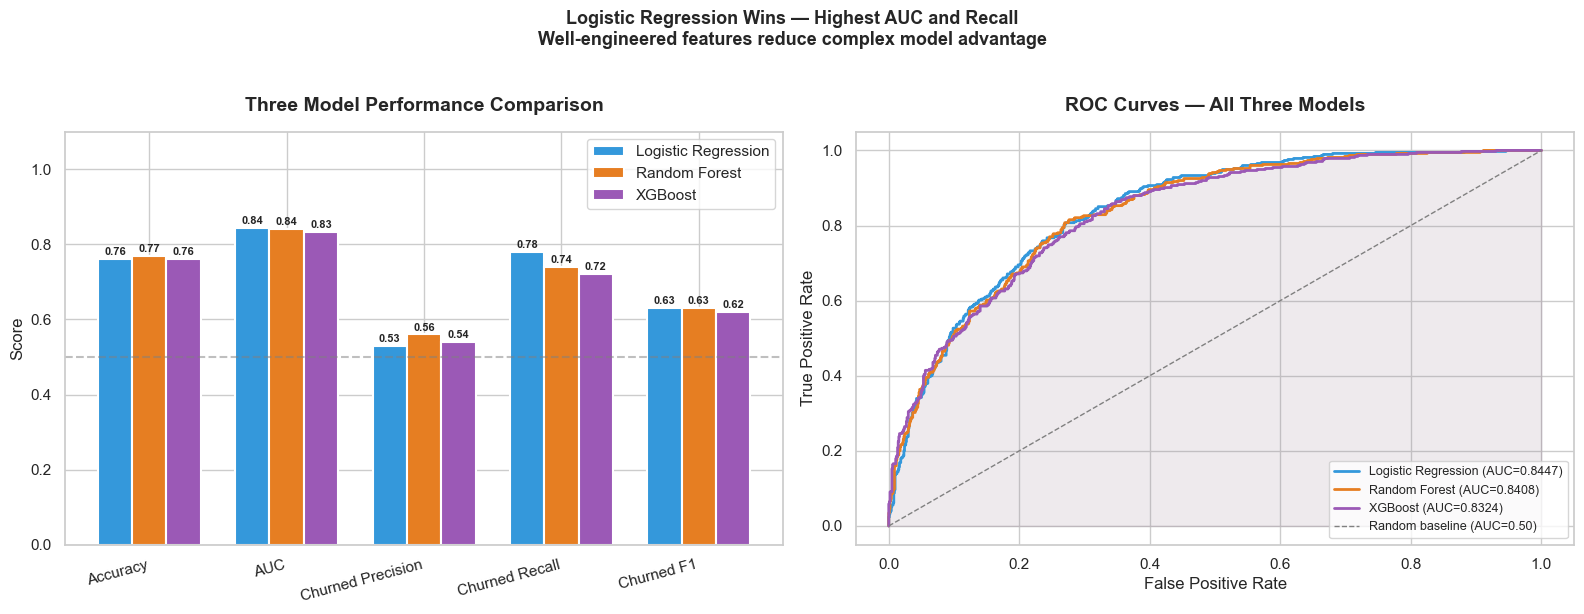

Three model comparison chart saved


In [5]:
# ============================================
# Cell 4: Three Model Comparison
# Purpose: Visual comparison of all three models
# ============================================

# --- Prepare comparison data ---
metrics = {
    'Metric': [
        'Accuracy', 'AUC',
        'Churned Precision', 'Churned Recall',
        'Churned F1'
    ],
    'Logistic Regression': [0.76, 0.8447, 0.53, 0.78, 0.63],
    'Random Forest':       [0.77, 0.8408, 0.56, 0.74, 0.63],
    'XGBoost':             [0.76, 0.8324, 0.54, 0.72, 0.62]
}

comparison_df = pd.DataFrame(metrics).set_index('Metric')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left — grouped bar comparison ---
x = np.arange(len(comparison_df.index))
width = 0.25

bars1 = axes[0].bar(
    x - width, comparison_df['Logistic Regression'],
    width, label='Logistic Regression',
    color='#3498db', edgecolor='white', linewidth=1.5
)
bars2 = axes[0].bar(
    x, comparison_df['Random Forest'],
    width, label='Random Forest',
    color='#e67e22', edgecolor='white', linewidth=1.5
)
bars3 = axes[0].bar(
    x + width, comparison_df['XGBoost'],
    width, label='XGBoost',
    color='#9b59b6', edgecolor='white', linewidth=1.5
)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.2f}',
            ha='center', va='bottom',
            fontsize=8, fontweight='bold'
        )

axes[0].set_xticks(x)
axes[0].set_xticklabels(
    comparison_df.index,
    rotation=15, ha='right'
)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Three Model Performance Comparison', pad=15)
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].axhline(
    y=0.5, color='gray',
    linestyle='--', alpha=0.5
)

# --- Right — ROC curves all three ---
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

axes[1].plot(lr_fpr, lr_tpr, color='#3498db',
             linewidth=2,
             label=f'Logistic Regression (AUC=0.8447)')
axes[1].plot(rf_fpr, rf_tpr, color='#e67e22',
             linewidth=2,
             label=f'Random Forest (AUC=0.8408)')
axes[1].plot(xgb_fpr, xgb_tpr, color='#9b59b6',
             linewidth=2,
             label=f'XGBoost (AUC=0.8324)')
axes[1].plot([0, 1], [0, 1], color='gray',
             linewidth=1, linestyle='--',
             label='Random baseline (AUC=0.50)')

axes[1].fill_between(lr_fpr, lr_tpr, alpha=0.05, color='#3498db')
axes[1].fill_between(rf_fpr, rf_tpr, alpha=0.05, color='#e67e22')
axes[1].fill_between(xgb_fpr, xgb_tpr, alpha=0.05, color='#9b59b6')

axes[1].set_title('ROC Curves — All Three Models', pad=15)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right', fontsize=9)

plt.suptitle(
    'Logistic Regression Wins — Highest AUC and Recall\n'
    'Well-engineered features reduce complex model advantage',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../outputs/figures/09_model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Three model comparison chart saved")

## Multicollinearity Finding

**tenure vs totalcharges correlation: 0.829** — high multicollinearity.
Both features measure customer longevity from different angles.

**Fix:** engineered `avg_monthly_spend = totalcharges / tenure` in notebook 03 before scaling.

**Result:**
- Correlation reduced from 0.829 → 0.222 ✅
- avg_monthly_spend range: $18-$119 (matches monthly charges) ✅
- Impact on AUC: negligible (-0.002)

**Conclusion:** Models were robust to multicollinearity but
`avg_monthly_spend` is a cleaner, more interpretable feature.
A stakeholder immediately understands "average monthly spend" vs "total charges accumulated over tenure."

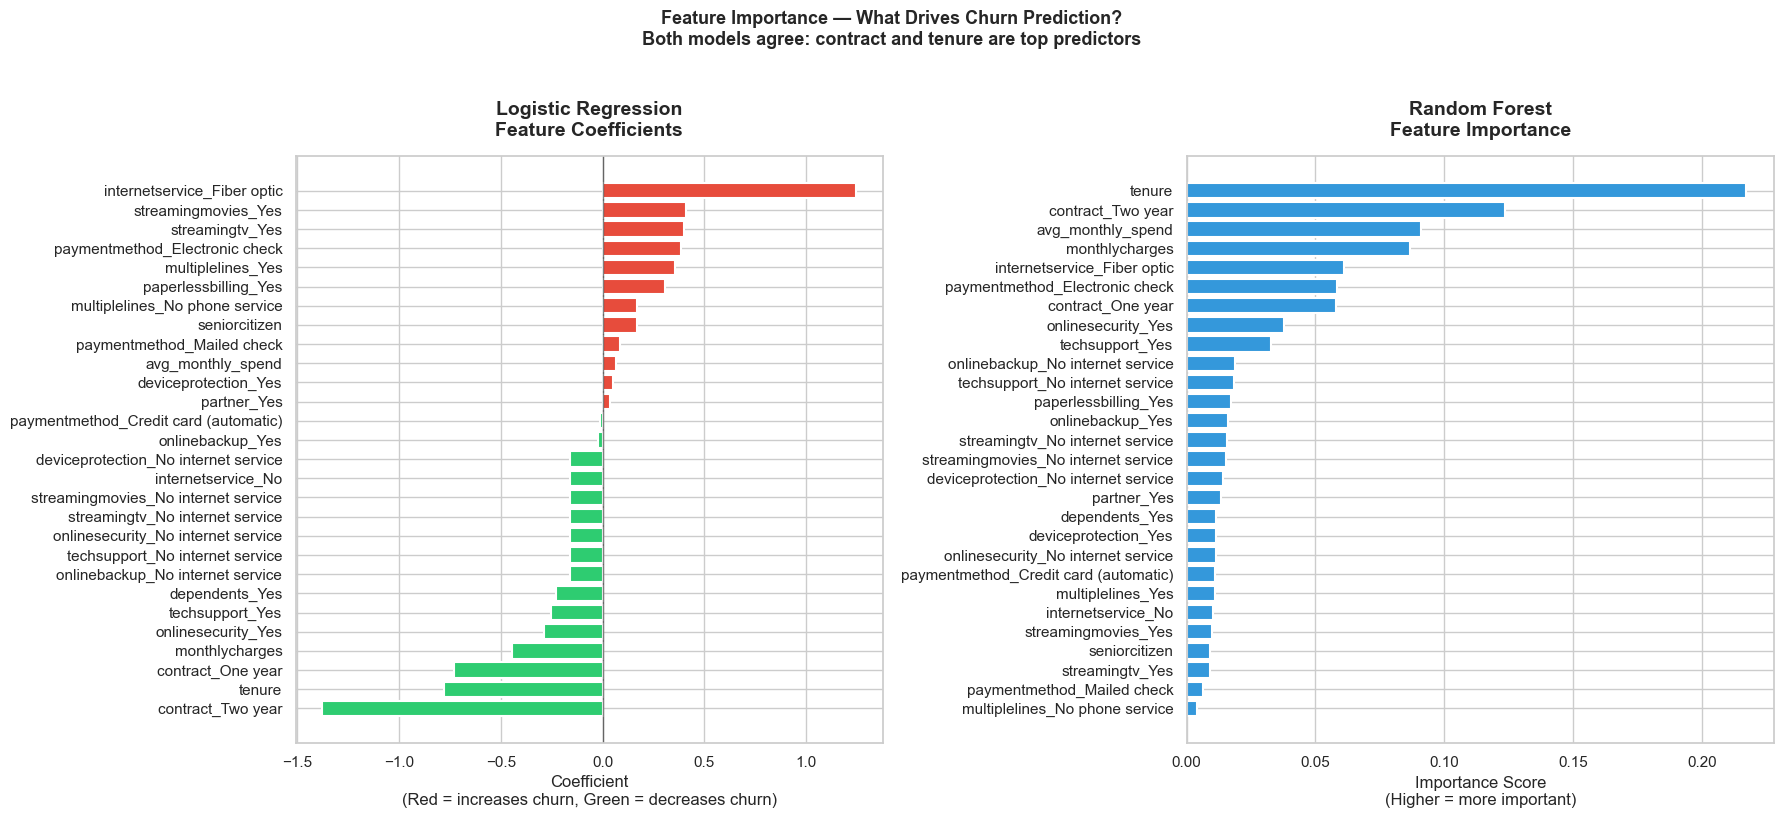

=== TOP 10 FEATURES — RANDOM FOREST ===
tenure                              0.217097
contract_Two year                   0.123751
avg_monthly_spend                   0.090858
monthlycharges                      0.086822
internetservice_Fiber optic         0.061177
paymentmethod_Electronic check      0.058197
contract_One year                   0.057794
onlinesecurity_Yes                  0.037791
techsupport_Yes                     0.032910
onlinebackup_No internet service    0.018671
dtype: float64

=== TOP 10 FEATURES — LOGISTIC REGRESSION ===
contract_Two year                 1.376164
internetservice_Fiber optic       1.245191
tenure                            0.779893
contract_One year                 0.731174
monthlycharges                    0.443006
streamingmovies_Yes               0.411524
streamingtv_Yes                   0.399995
paymentmethod_Electronic check    0.385707
multiplelines_Yes                 0.353278
paperlessbilling_Yes              0.307153
dtype: float64


In [8]:
# ============================================
# Cell 5: Feature Importance
# Purpose: Which features does each model consider most important for predicting churn?
# Logistic Regression — uses coefficients
# Random Forest — uses mean decrease in impurity
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Left — Logistic Regression coefficients ---
lr_importance = pd.Series(
    lr_model.coef_[0],
    index=X_train.columns
).sort_values()

colors_lr = ['#e74c3c' if x > 0 else '#2ecc71'
             for x in lr_importance.values]

axes[0].barh(
    lr_importance.index,
    lr_importance.values,
    color=colors_lr,
    edgecolor='white',
    linewidth=1.5
)
axes[0].axvline(x=0, color='black', linewidth=1, alpha=0.5)
axes[0].set_title(
    'Logistic Regression\nFeature Coefficients',
    pad=15
)
axes[0].set_xlabel(
    'Coefficient\n(Red = increases churn, Green = decreases churn)'
)

# --- Right — Random Forest feature importance ---
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values()

axes[1].barh(
    rf_importance.index,
    rf_importance.values,
    color='#3498db',
    edgecolor='white',
    linewidth=1.5
)
axes[1].set_title(
    'Random Forest\nFeature Importance',
    pad=15
)
axes[1].set_xlabel(
    'Importance Score\n(Higher = more important)'
)

plt.suptitle(
    'Feature Importance — What Drives Churn Prediction?\n'
    'Both models agree: contract and tenure are top predictors',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../outputs/figures/10_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print top 10 most important features
print("=== TOP 10 FEATURES — RANDOM FOREST ===")
print(rf_importance.sort_values(ascending=False).head(10))

print("\n=== TOP 10 FEATURES — LOGISTIC REGRESSION ===")
print(lr_importance.abs().sort_values(ascending=False).head(10))